In [1]:
# Standard code libraries
import faulthandler

from matplotlib import pyplot as plt

# Custom code libraries from ReSurfEMG
from resurfemg.data_connector.data_classes import EmgDataGroup
from resurfemg.helper_functions.visualization import show_power_spectrum
from resurfemg.pipelines import synthetic_data as synth
import numpy as np

faulthandler.enable()

%matplotlib widget

def notch_powerline_harmonics(y, fs, f0=50, q=30):
    """Notch filter the powerline harmonics from the signal.

    Parameters
    ----------
    y : array-like
        The input signal.
    fs : float
        The sampling frequency of the signal.
    f0 : float, optional
        The fundamental frequency of the powerline noise (default is 50 Hz).
    n_harmonics : int, optional
        The number of harmonics to notch filter (default is 21).
    q : float, optional
        The quality factor for the notch filter (default is 30).

    Returns:
    -------
    y_filtered : array-like
        The filtered signal with powerline harmonics removed.
    """
    from scipy.signal import iirnotch, filtfilt
    f_nyquist = fs / 2
    n_harmonics = int(f_nyquist // f0)
    y_filtered = y.copy()
    for k in range(1, n_harmonics + 1):
        f_harmonic = k * f0
        b, a = iirnotch(f_harmonic / (fs / 2), q)
        y_filtered = filtfilt(b, a, y_filtered)

    return y_filtered

In [2]:

# Recording parameters
import random


t_rec = 7 * 60  # Recording duration (s)
fs_vent = 100  # Sampling rate of ventilator (Hz)
fs_emg = 2048  # Sampling rate of EMG amplifier (Hz)

# Ventilator parameters
dp = 8  # Driving pressure above PEEP (cmH2O)

# Patient respiratory variables
ie_ratio = 1 / 2  # Ratio between inspiratory and expiratory time
rr = 22  # Respiratory rate (/min)
p_mus_max_0_PEEP = 10  # Maximal respiratory muscle pressure (cmH2O)
c = 0.050  # Respiratory system compliance (L/cmH2O)
r = 5  # Respiratory system resistance (cmH2O/L/s)
p_ip = -5  # Static interpleural pressure (cmH2O)

tau_mus_up = 0.3  # Muscle contraction time constant
tau_mus_down = 0.3  # Muscle release time constant

# Cardiac parameters
hr_min = 60  # Minimal heart rate (bpm)
hr_max = 100  # Maximal heart rate (bpm)

# Occlussion manoeuvre (Pocc) settings
t_occs = np.array([t_rec - 45, t_rec - 30, t_rec - 15])
t_occs = np.floor(t_occs * rr / 60) * 60 / rr  # Sync Poccs with respiratory pattern
for i, t_occ in enumerate(t_occs):
    if t_rec < (t_occ + 60 / rr):
        print("t=" + str(t_occ) + ": t_occ should be at least a full " + "respiratory cycle from t_end")

hr = random.randint(hr_min, hr_max)


def sim_amp(emg_amp):
    return synth.simulate_raw_emg(
    t_p_occs=t_occs,
    t_end=t_rec,
    fs_emg=fs_emg,
    rr=rr,
    ie_ratio=ie_ratio,
    tau_mus_up=0.3,
    tau_mus_down=0.3,
    emg_amp=emg_amp,  # Approximate EMG-RMS amplitude (uV)
    drift_amp=100,  # Approximate drift RMS amplitude (uV)
    noise_amp=2,  # Approximate baseline noise RMS amplitude (uV)
    heart_rate=hr,
    ecg_acceleration=1.6,
    powerline_amp=15,            # >0 turns mains on; ~10-20 for visible, higher for spike-dominated
    powerline_freq=50,           # 60 for US mains
    powerline_n_harmonics=11,
    powerline_harmonic_decay=.8,
    powerline_freq_drift=0.1,
    phase_jitter = 3,
    harmonic_jitter = 0.6)

emg_corrupted = np.zeros((2, int(fs_emg * t_rec)))
emg_corrupted[0] = sim_amp(0.2)
emg_corrupted[1] = sim_amp(5)

# Simulate ventilator data
p_mus_amp = 5
t_occs_vent = t_occs
y_vent, p_mus = synth.simulate_ventilator_data(
    t_end=t_rec,
    fs_vent=fs_vent,
    p_mus_amp=p_mus_amp,
    rr=rr,
    dp=dp,
    t_p_occs=t_occs_vent,
)

In [ ]:
fs = 1024


# emg_corrupted = synth.simulate_raw_emg(
#     t_end=300,
#     fs_emg=fs_emg,
#     emg_amp=5,
#     rr=22,
#     # powerline_amp=15,            # >0 turns mains on; ~10-20 for visible, higher for spike-dominated
#     # powerline_freq=50,           # 60 for US mains
#     # powerline_n_harmonics=11,
#     # powerline_harmonic_decay=.8,
#     # powerline_freq_drift=0.1,
#     # phase_jitter = 3,
#     # harmonic_jitter = 0.6
# )
emg_timeseries = EmgDataGroup(
    y_raw = np.array(emg_corrupted),
    fs = fs_emg,
    labels = ["sim1", "sim2"]
)



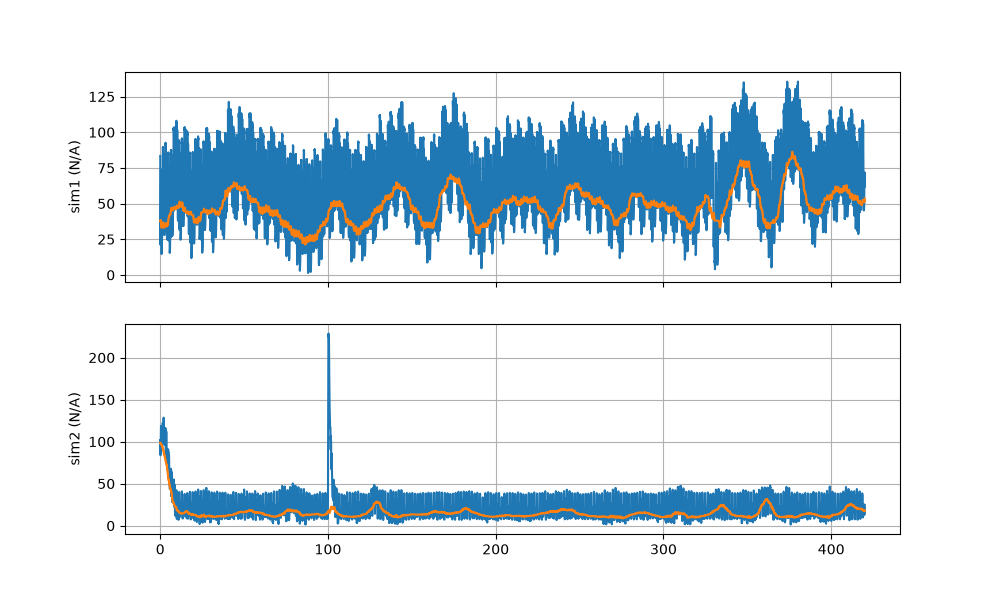

: 

In [ ]:

for i in range(len(emg_timeseries.channels)):
    emg_timeseries[i]['filt'] = notch_powerline_harmonics(emg_timeseries[i]['filt'], fs_emg, f0=50, q=30)
# emg_timeseries.get_ecg_peaks(overwrite=True)
emg_timeseries.gating(signal_io=("filt", "clean"), overwrite=True)
emg_timeseries.envelope()
emg_timeseries.baseline()
emg_timeseries.plot_full()

Text(0.5, 0, 't (s)')

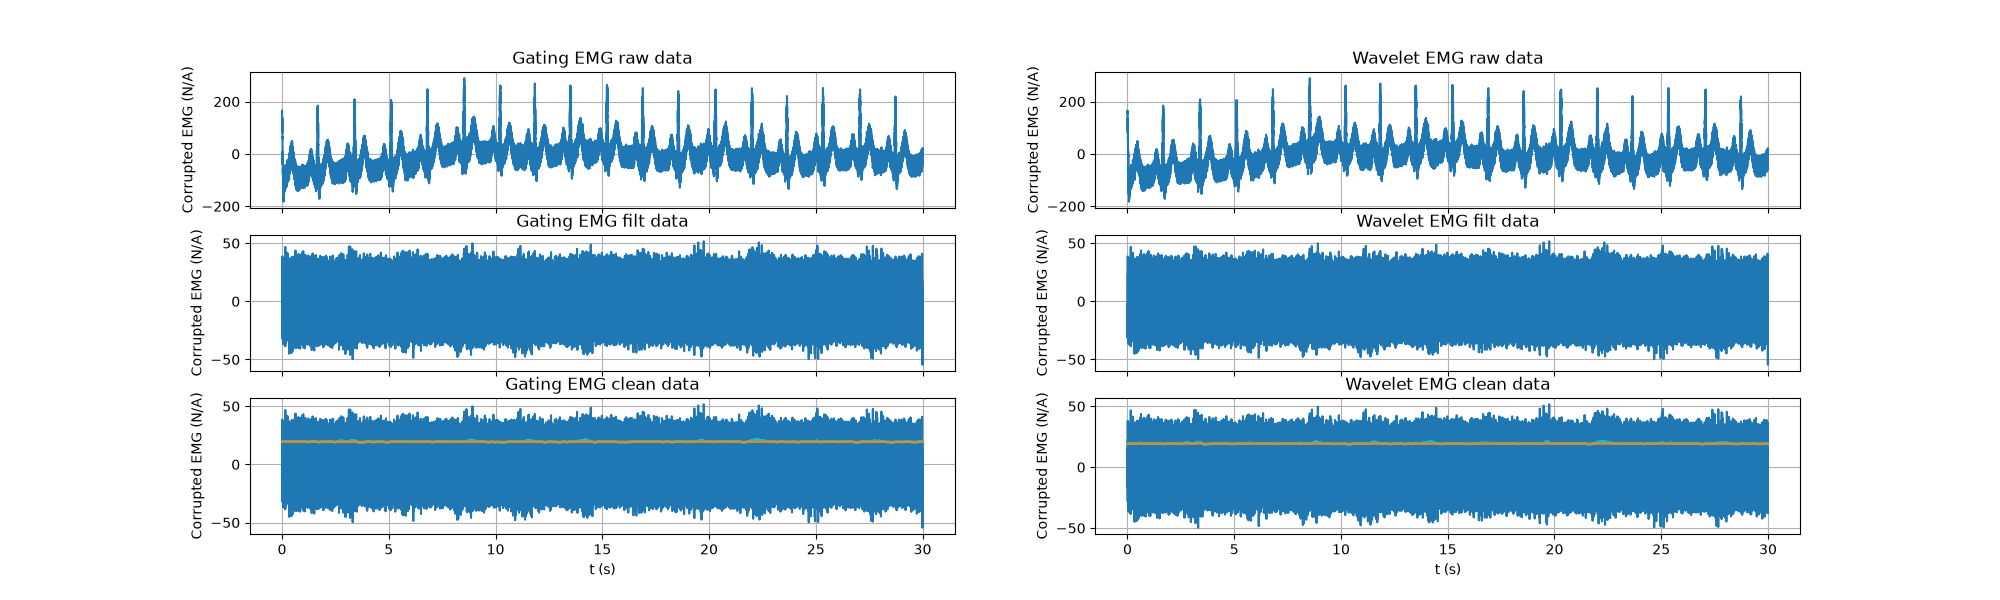

In [58]:

# Filter
emg_timeseries_gating.filter()
emg_timeseries_wavelet.filter()

# ECG removal
# ECG peak detection:
emg_timeseries_gating.get_ecg_peaks(overwrite=True)
emg_timeseries_wavelet.get_ecg_peaks(overwrite=True)
# OR Set the peaks manually:
# emg_timeseries_gating.set_peaks(ecg_peak_idxs, y_ecg, 'ecg', overwrite=True)

# # Through gating
# emg_timeseries_gating.wavelet_denoising()
# emg_timeseries_wavelet.wavelet_denoising()
emg_timeseries_gating.gating()
emg_timeseries_wavelet.wavelet_denoising()
# # Through wavelet denoising
# emg_timeseries_gating.wavelet_denoising()
# # emg_timeseries_gating.wavelet_denoising(n=8, fixed_threshold=8.0)
# Calculate the envelope of the signal
emg_timeseries_gating.envelope()
emg_timeseries_wavelet.envelope()
# emg_timeseries_gating.envelope(ci_alpha=0.05)
# emg_timeseries.envelope(env_type='arv')
# emg_timeseries.envelope(env_type='arv', ci_alpha=0.05)
# Calculate the baseline for the EMG envelopes and p_vent
emg_timeseries_gating.baseline()
emg_timeseries_wavelet.baseline()
# Plot the raw data with the envelope
# EMG data
n_rows = len(emg_timeseries_gating.channels) + 1
fig, axes_emg = plt.subplots(nrows=n_rows, ncols=2, figsize=(20, n_rows * 2), sharex=True)
# axes_emg = axis[: len(emg_timeseries_gating.channels), 0]
colors = ["tab:cyan", "tab:orange"]

for i, key in enumerate(["raw", "filt", "clean"]):
    emg_timeseries_gating.channels[0].plot_full(axes=axes_emg[i, 0], signal_io=(key,), baseline_bool=False)
    emg_timeseries_wavelet.channels[0].plot_full(axes=axes_emg[i, 1], signal_io=(key,), baseline_bool=False)
    axes_emg[i, 0].set_title(f"Gating EMG {key} data")
    axes_emg[i, 1].set_title(f"Wavelet EMG {key} data")
emg_timeseries_gating.channels[0].plot_full(axes=axes_emg[-1, 0], signal_io=("baseline",), baseline_bool=False)
emg_timeseries_gating.channels[0].plot_full(axes=axes_emg[-1, 0], signal_io=("env",), colors=colors)
emg_timeseries_wavelet.channels[0].plot_full(axes=axes_emg[-1, 1], signal_io=("baseline",), baseline_bool=False)
emg_timeseries_wavelet.channels[0].plot_full(axes=axes_emg[-1, 1], signal_io=("env",), colors=colors)
# axes_emg[0].set_title("EMG data")
axes_emg[-1, 0].set_xlabel("t (s)")
# axes_emg[-1, 0].set_xlim([5, 5.5])
axes_emg[-1, 1].set_xlabel("t (s)")
# axes_emg[-1, 1].set_xlim([5, 5.5])
# if n_rows > len(emg_timeseries_gating.channels):
#     for ax_idx in range(len(emg_timeseries_gating.channels), n_rows):
#         axes_emg[ax_idx].axis("off")
#     axes_emg[len(emg_timeseries_gating.channels) - 1].tick_params(axis="x", which="both", labelbottom=True)


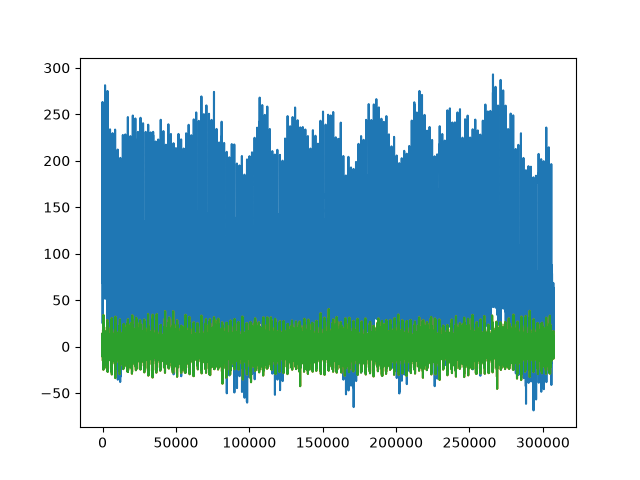

In [75]:
plt.figure()
emg_timeseries_gating.filter()
emg_timeseries_wavelet.filter()
plt.plot(emg_timeseries_wavelet.channels[0].y_data["raw"])
plt.plot(emg_timeseries_wavelet.channels[0].y_data["filt"])
plt.plot(emg_timeseries_gating.channels[0].y_data["filt"])
plt.show()

In [63]:
emg_timeseries_gating.fs

2048